In [1]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653917 sha256=b119c4238c60bbcee669574832482de74792ea43fc86da399040b4f3d5fc519a
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [2]:
import os
from pathlib import Path
from fasttext import load_model
import pandas as pd
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA



**Primer apartado**

In [3]:
os.makedirs("data", exist_ok=True)

os.makedirs("data", exist_ok=True)

model_path = Path("data/cc.en.300.bin")

if model_path.exists():
    print("El modelo ya está descargado.")
else:
    print("Descargando modelo FastText...")

    !wget -O data/cc.en.300.bin.gz \https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz

    print("Descomprimiendo archivo...")
    !gunzip -f data/cc.en.300.bin.gz

    print("Descarga completada.")

Descargando modelo FastText...
--2026-05-27 20:29:47--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.8.54.65, 65.8.54.33, 65.8.54.85, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.8.54.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4503593528 (4.2G) [application/octet-stream]
Saving to: ‘data/cc.en.300.bin.gz’

data/cc.en.300.bin. 100%[===================>]   4.19G  54.2MB/s    in 80s     

2026-05-27 20:31:08 (53.6 MB/s) - ‘data/cc.en.300.bin.gz’ saved [4503593528/4503593528]

Descomprimiendo archivo...
Descarga completada.


In [4]:
# Cargar el modelo FastText preentrenado
model = load_model("data/cc.en.300.bin")

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [5]:
os.makedirs("data", exist_ok=True)

if not os.path.exists("data/country-list.csv"):
    !wget -O data/country-list.csv \https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/country-list.csv

    print("Archivo descargado.")
else:
    print("El archivo ya existe.")

--2026-05-27 20:33:21--  https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/country-list.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5011 (4.9K) [text/plain]
Saving to: ‘data/country-list.csv’

data/country-list.c 100%[===================>]   4.89K  --.-KB/s    in 0s      

2026-05-27 20:33:21 (44.3 MB/s) - ‘data/country-list.csv’ saved [5011/5011]

Archivo descargado.


In [6]:
df = pd.read_csv("data/country-list.csv")

print(df.head())
print(df.shape)

                 country              capital
0               Abkhazia              Sukhumi
1            Afghanistan                Kabul
2  Akrotiri and Dhekelia  Episkopi Cantonment
3                Albania               Tirana
4                Algeria              Algiers
(248, 2)


In [7]:
words = []

for _, row in df.iterrows():
    country = str(row["country"]).strip()
    capital = str(row["capital"]).strip()

    words.append(country)
    words.append(capital)
# Eliminar duplicados
words = list(set(words))

print(f"Cantidad de palabras: {len(words)}")

Cantidad de palabras: 484


In [8]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

In [9]:
embeddings = {}

for word in words:
    embeddings[word] = model[word]

**Analogías**

El modelo descargado de FastText asocia n palabras con matrices de dimension n, donde la posición en el espacio de cada palabra depende de las palabras con las que está relacionada, por esto es que se puede utilizar para "predecir" analogías del tipo X es a C como A es a B. Primero se limita el conjunto de embeddings a solamente ciertos paises y sus capitales, para luego comparar mendiante una proyección (similitud coseno, utilizando la formula del angulo entre vectores, si estos son iguales su producto interno es la norma y vale uno, si son ortogonales el producto interno es cero y todo vale cero)

In [10]:
def analogy(A, B, C, top_k=3):

    # Operación vectorial
    target = (
        model[B]
        - model[A]
        + model[C]
    )

    similarities = []

    for word, vec in embeddings.items():

        # Evitar devolver palabras usadas
        if word in [A, B, C]:
            continue

        sim = cosine_similarity(target, vec)
        similarities.append((word, sim))

    # Ordenar por similitud
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_k]



In [11]:
examples = [
    ("France", "Paris", "United Kingdom; England"),
    ("Germany", "Berlin", "Spain"),
    ("Japan", "Tokyo", "China"),
    ("Argentina", "Buenos Aires", "Brazil"),
]

for A, B, C in examples:

    results = analogy(A, B, C)

    print(f"\n{A} es a {B} como {C} es a:\n")

    for word, score in results:
        print(f"{word:20s} similitud = {score:.4f}")


France es a Paris como United Kingdom; England es a:

London               similitud = 0.4450
Tokyo                similitud = 0.4137
Copenhagen           similitud = 0.3955

Germany es a Berlin como Spain es a:

Madrid               similitud = 0.8003
Lisbon               similitud = 0.6288
Portugal             similitud = 0.6180

Japan es a Tokyo como China es a:

Beijing              similitud = 0.8571
Taipei               similitud = 0.6486
Seoul                similitud = 0.6327

Argentina es a Buenos Aires como Brazil es a:

Brasília             similitud = 0.4647
South Africa         similitud = 0.4454
Phnom Penh           similitud = 0.4322


Se puede ver como el método funciona bien, ya que en todos los casos la primer opcion es la correcta.

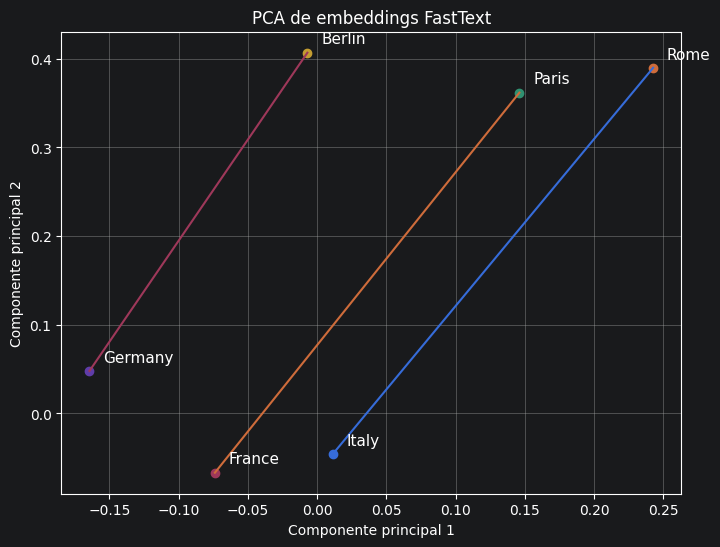

In [12]:

# =========================
# Palabras a graficar
# =========================
selected_words = [
    "Italy", "Rome",
    "France", "Paris",
    "Germany", "Berlin"
]

# =========================
# Construir matriz de embeddings
# =========================
X = np.array([model[word] for word in selected_words])

# =========================
# PCA a 2 dimensiones
# =========================
pca = PCA(n_components=2, random_state= 10072003)

X_train = np.array([model[word] for word in words])

pca.fit(X_train)


X_2d = pca.transform(X)

# =========================
# Graficar
# =========================
plt.figure(figsize=(8, 6))

for i, word in enumerate(selected_words):

    x, y = X_2d[i]

    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=11)

# =========================
# Unir países con capitales
# =========================
pairs = [
    ("Italy", "Rome"),
    ("France", "Paris"),
    ("Germany", "Berlin")
]

for country, capital in pairs:

    i = selected_words.index(country)
    j = selected_words.index(capital)

    x_values = [X_2d[i, 0], X_2d[j, 0]]
    y_values = [X_2d[i, 1], X_2d[j, 1]]

    plt.plot(x_values, y_values)

# =========================
# Estética
# =========================
plt.title("PCA de embeddings FastText")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)

plt.show()

Por ultimo, relizando una descomposicion de componentes principales a dimension 2, se puede ver la similitud entre los segmentos que unen los paises con sus capitales. Todos tienen la misma direccion y la misma longitud, de esta forma se puede ver de forma gráfica el funcionamiento del método utilizado para las analogías.

**Segundo apartado**

In [13]:
os.makedirs("data", exist_ok=True)

if not os.path.exists("data/materias.csv"):
    !wget -O data/materias.csv \https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/materias.csv

    print("Archivo descargado.")
else:
    print("El archivo ya existe.")

--2026-05-27 20:33:24--  https://raw.githubusercontent.com/mvera1412/tallerPS/main/data/materias.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5751 (5.6K) [text/plain]
Saving to: ‘data/materias.csv’

data/materias.csv   100%[===================>]   5.62K  --.-KB/s    in 0s      

2026-05-27 20:33:24 (48.3 MB/s) - ‘data/materias.csv’ saved [5751/5751]

Archivo descargado.


In [14]:
dataset_materias = pd.read_csv("data/materias.csv")
dataset_materias.head()

,[Introducción al Conocimiento de la Sociedad y el Estado (CBC)],[Introducción al Pensamiento Científico (CBC)],[Análisis Matemático A (CBC)],[Álgebra A (CBC)],[Física (CBC)],[Pensamiento Computacional (CBC)],[Análisis Matemático II],[Física de los Sistemas de Partículas],[Introducción a la Ingeniería Electrónica],[Algoritmos y Programación],...,[Algoritmos y Estructuras de Datos],[Sistemas Operativos Embebidos],[Control Automático Multivariable],[Electrónica de Potencia],[Robótica Móvil],[Robótica Industrial],[Comunicación y Computación Cuántica],[Introducción a la Ingeniería Acústica],[Ciberseguridad de Redes e Infraestructuras Críticas],"[Introducción a la industria, los Sistemas y el Negocio Aeroespacial]"
0,NaN,Positiva,Positiva,Positiva,Positiva,NaN,Positiva,Positiva,Positiva,Positiva,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Positiva,Positiva,Positiva,NaN,Positiva,NaN,Positiva,Positiva,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Negativa,NaN,Positiva,Positiva,Positiva,NaN,NaN,Positiva,Positiva,Positiva,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Positiva,Positiva,Positiva,Negativa,NaN,Positiva,Negativa,Positiva,Positiva,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Positiva,Positiva,Positiva,Positiva,Positiva,Positiva,Positiva,Positiva,Positiva,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
dataset_materias = dataset_materias.fillna(0)

dataset_materias = dataset_materias.replace({
    "Positiva": 1,
    "Negativa": -1
})

dataset_materias.head()

/tmp/ipykernel_4064/4130783802.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset_materias = dataset_materias.replace({


,[Introducción al Conocimiento de la Sociedad y el Estado (CBC)],[Introducción al Pensamiento Científico (CBC)],[Análisis Matemático A (CBC)],[Álgebra A (CBC)],[Física (CBC)],[Pensamiento Computacional (CBC)],[Análisis Matemático II],[Física de los Sistemas de Partículas],[Introducción a la Ingeniería Electrónica],[Algoritmos y Programación],...,[Algoritmos y Estructuras de Datos],[Sistemas Operativos Embebidos],[Control Automático Multivariable],[Electrónica de Potencia],[Robótica Móvil],[Robótica Industrial],[Comunicación y Computación Cuántica],[Introducción a la Ingeniería Acústica],[Ciberseguridad de Redes e Infraestructuras Críticas],"[Introducción a la industria, los Sistemas y el Negocio Aeroespacial]"
0,0,1,1,1,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
2,-1,0,1,1,1,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,1,-1,0,1,-1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


**Recomendaciones**

Se busca predecir gustos de una persona, comparandola con otras personas con las que comparte gustos y teniendo en cuenta las cosas más gustadas en general, para esto, se utilizará un filtro colaborativo, cuyos parámetros se buscan ajustar a traves de un gradiente descendiente, para lo que primero se busca obtener la formula del gradiente

Partiendo desde la matriz de calificaciones:
$$
Y \in \mathbb{N}^{n_{items}\times n_{users}}
$$

Donde cada entrada $y_{i,j}$ representa la opinión de cada usuario $j$ sobre el item $i$.

Definiendo $\hat y_{i,j} = θ_j^Tx_i$, la función de costo regularizada se escribe:

$$
J(X, \Theta) = \frac{1}{2} \sum_{(i,j) \in R} \left( \theta_{j}^T x_{i} - y_{i,j} \right)^2 + \frac{\lambda}{2}\left( \sum_{i=1}^{n_u} \|x_{i}\|^2 + \sum_{j=1}^{n_m} \|\theta_{j}\|^2\right)
 $$

donde $R$ es el conjunto de pares $(i,j)$ para los que existe una calificación real $y_{i,j}$

Los parámetros a ajustar resultan

$$
x \in \mathbb{R}^{n_{items}\times ν}
$$

$$
θ \in \mathbb{R}^{n_{users}\times ν}
$$

Siendo $ν$ la dimensión del espacio latente en donde los datos se agrupan según su similitud y se representan de manera comprimida.

Para calcular el gradiente respecto a $x$ se realizará por un lado la derivada del término del error y por el otro el del la regularización.

Para el caso del término del error todas las derivadas de los términos con $(i,j) \neq (i,j)$ se anulan.

$$
\frac{∂J_{error}}{\partial x_i} =  \sum_{j : (i,j) \in R} \left( \theta_{j}^T x_{i} - y_{i,j} \right) \cdot \frac{\partial}{\partial x_{i}} \left[\theta_{j}^T x_{i} \right] = \sum_{j : (i,j) \in R} \left( \theta_{j}^T x_{i} - y_{i,j} \right) \theta_{j}
$$

Para el termino de la regualirización nuevamente se anulan la mayoría de los términos, permaneciendo unicamente el que depende de $x_i$

$$
\frac{\partial J_{reg}}{\partial x_i} = \lambda \frac{\partial}{\partial x_{i}} \left[ \frac{1}{2}\|x_{i}\|^2 \right] =λ x_{i}
$$

Por lo tanto:
$$
\frac{\partial J}{\partial x_i} = \sum_{j : (i,j) \in R} \left( \theta_{j}^T x_{i} - y_{i,j} \right) \theta_{j} + λ x_{i}
$$

El caso del gradiente de $\theta$ resulta análogo al anterior, en este caso teniendo en cuenta los $j$, obteniendo:

$$
\frac{\partial J}{\partial \theta_j}  = \sum_{i : (i,j) \in R} \left( \theta_j^T x_i - y_{i,j} \right) x_i + \lambda \theta_j
$$

Por ultimo, para expresar de forma vectorial:
$$
X = [x_1 \; x_2 \;...]^T
$$

$$
Θ = [θ_1 \; θ_2 \; ...]^T
$$

Como no se tienen todos los datos, ya que pueden no haber opiniones de todas los items, el error se calculará sólamente con los datos existentes:

$$
e_{i,j} = \begin{cases} \theta_j^T x_i - y_{i,j} & \text{si } (i,j) \in R \\ 0 & \text{en otro caso} \end{cases}
$$

Los gradientes obtenidos y posteriormente implementados son los siguientes:

$$
\nabla_{X} J = E\cdot \Theta + \lambda X
$$

$$
\nabla_{\Theta} J = E^T \cdot X + \lambda \Theta
$$

In [16]:
class CollaborativeFiltering:

    def __init__(self):

        self.X = None              # Usuarios
        self.Theta = None          # Items/Materias

        self.loss_history = None

        self.item_means = None

    # =========================
    # Función de costo
    # =========================
    def cost_function(self, Y, R):

        error = R * (self.X @ self.Theta.T - Y)

        cost = 0.5 * np.sum(error**2)

        # Regularización
        cost += (self.lambda_ / 2) * np.sum(self.X**2)

        cost += (self.lambda_ / 2) * np.sum(self.Theta**2)

        return cost

    # =========================
    # Gradientes
    # =========================
    def gradients(self, Y, R):

        error = R * (self.X @ self.Theta.T - Y)

        dX = error @ self.Theta + self.lambda_ * self.X

        dTheta = error.T @ self.X + self.lambda_ * self.Theta

        return dX, dTheta

    # =========================
    # Entrenamiento
    # =========================
    def fit(
        self,
        Y,
        latent_dim=10,
        lambda_=0.1,
        alpha=0.001,
        epochs=1000,
        random_state=10072003,
        verbose=True
    ):

        np.random.seed(random_state)

        self.lambda_ = lambda_
        self.alpha = alpha
        self.latent_dim = latent_dim

        # =========================
        # Dimensiones
        # =========================
        n_users, n_items = Y.shape

        # =========================
        # Máscara
        # =========================
        R = (Y != 0).astype(float)

        # =========================
        # Media por item/materia
        # =========================
        counts = np.sum(R, axis=0)

        self.item_means = (
            np.sum(Y, axis=0)
            /
            np.maximum(counts, 1)
        )

        # =========================
        # Inicialización
        # =========================
        self.X = np.random.randn(
            n_users,
            latent_dim
        )

        self.Theta = np.random.randn(
            n_items,
            latent_dim
        )

        self.loss_history = []

        # =========================
        # Gradient Descent
        # =========================
        for epoch in range(epochs):

            dX, dTheta = self.gradients(Y, R)

            self.X -= alpha * dX

            self.Theta -= alpha * dTheta

            loss = self.cost_function(Y, R)

            self.loss_history.append(loss)

            if verbose and epoch % 100 == 0:
                print(
                    f"Epoch {epoch:4d} | "
                    f"Loss: {loss:.4f}"
                )

        return self

    # =========================
    # Predicciones completas
    # =========================
    def predict_all(self, p=0.8):

        # Collaborative filtering
        cf_pred = self.X @ self.Theta.T

        # Expandir medias
        means = self.item_means[np.newaxis, :]

        # Combinación ponderada
        predictions = (
            p * cf_pred
            +
            (1 - p) * means
        )

        return predictions

    # =========================
    # Predicción individual
    # =========================
    def predict(self, user_idx, item_idx, p=0.8):

        cf_pred = (
            self.X[user_idx]
            @
            self.Theta[item_idx]
        )

        mean_pred = self.item_means[item_idx]

        prediction = (
            p * cf_pred
            +
            (1 - p) * mean_pred
        )

        return prediction

    # =========================
    # Graficar convergencia
    # =========================
    def plot_convergence(self):

        plt.figure(figsize=(8, 5))

        plt.plot(self.loss_history)

        plt.xlabel("Epoch")

        plt.ylabel("Loss")

        plt.title(
            "Convergencia del entrenamiento"
        )

        plt.grid(True)

        plt.show()

        # =========================
    # Recomendaciones para un usuario
    # =========================
   # =========================
    # Recomendar para un alumno nuevo
    # =========================
    def recommend_from_profile(
        self,
        dataset,
        profile,
        top_k=5,
        p=0.8,
        only_unrated=True
    ):

        # =========================
        # Embedding del nuevo usuario
        # =========================
        #
        # Resolvemos:
        #
        # profile ≈ x @ Theta^T
        #
        # usando mínimos cuadrados
        #

        x_user = np.linalg.pinv(self.Theta) @ profile

        # Predicción collaborative filtering
        cf_pred = x_user @ self.Theta.T

        # Combinar con medias
        predictions = (
            p * cf_pred
            +
            (1 - p) * self.item_means
        )

        subjects = dataset.columns.tolist()

        recommendations = []

        for item_idx, score in enumerate(predictions):

            # Ignorar materias ya calificadas
            if only_unrated:

                if profile[item_idx] != 0:
                    continue

            recommendations.append(
                (subjects[item_idx], score)
            )

        recommendations.sort(
            key=lambda x: x[1],
            reverse=True
        )

        return recommendations[:top_k]

El objetivo del filtro es obtener recomendaciones, para esto se utilizará la prediccion obtenida en base al entrenamiento más el promedio de cada una de las materias. para esto se utiliza la siguiente formula:
$$
\hat{y}_{i,j} = p(\theta_{j}^T \cdot x_{i}) + (1-p)Ψ_i
$$

Donde:
* $\psi_i$ es el promedio de la materia
* $p$ es el peso de la personalización

$p$ indica el peso que se le da a la prediccion, es un valor entre 0 y 1, donde 1 implica solo tener en cuenta la prediccion y 1 implica solo tener en cuenta los valores medios por materia.

Epoch    0 | Loss: 281.8999
Epoch  100 | Loss: 19.8984
Epoch  200 | Loss: 17.5766
Epoch  300 | Loss: 16.3016
Epoch  400 | Loss: 15.9666
Epoch  500 | Loss: 15.8614
Epoch  600 | Loss: 15.7900
Epoch  700 | Loss: 15.7315
Epoch  800 | Loss: 15.6959
Epoch  900 | Loss: 15.6806
Epoch 1000 | Loss: 15.6748
Epoch 1100 | Loss: 15.6727
Epoch 1200 | Loss: 15.6719
Epoch 1300 | Loss: 15.6716
Epoch 1400 | Loss: 15.6715
Epoch 1500 | Loss: 15.6714
Epoch 1600 | Loss: 15.6714
Epoch 1700 | Loss: 15.6713
Epoch 1800 | Loss: 15.6713
Epoch 1900 | Loss: 15.6713


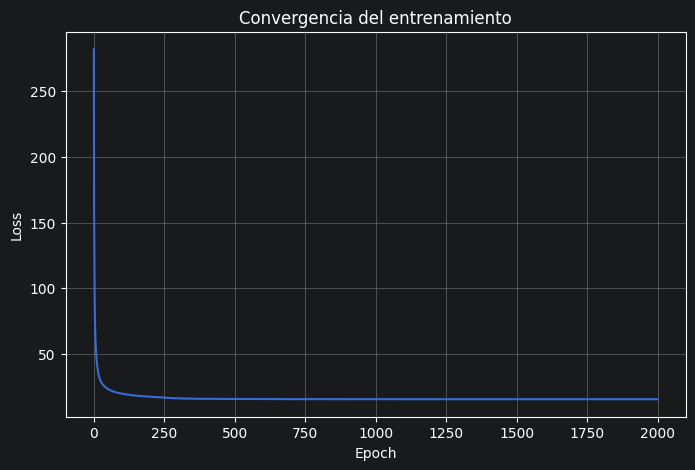

In [17]:
# =========================
# Matriz de ratings
# filas    -> usuarios
# columnas -> materias
# =========================

Y = dataset_materias.values.astype(float)

# =========================
# Crear modelo
# =========================
cf = CollaborativeFiltering()

# =========================
# Entrenar
# =========================
cf.fit(
    Y,
    latent_dim=5,
    lambda_=0.2,
    alpha=0.05,
    epochs=2000
)

# =========================
# Graficar convergencia
# =========================
cf.plot_convergence()



In [18]:
# =========================
# Crear un nuevo alumno
# =========================
def build_user_profile(
    dataset,
    liked_subjects=None,
    disliked_subjects=None
):
    dataset.columns = (
    dataset.columns
    .str.strip()
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

    liked_subjects = liked_subjects or []
    disliked_subjects = disliked_subjects or []

    # Vector vacío
    profile = np.zeros(len(dataset.columns))

    subject_to_idx = {
        subject: idx
        for idx, subject in enumerate(dataset.columns)
    }

    # Materias positivas
    for subject in liked_subjects:

        if subject in subject_to_idx:

            idx = subject_to_idx[subject]

            profile[idx] = 1

    # Materias negativas
    for subject in disliked_subjects:

        if subject in subject_to_idx:

            idx = subject_to_idx[subject]

            profile[idx] = -1

    return profile

In [19]:
nuevo_alumno = build_user_profile(
    dataset=dataset_materias,

    liked_subjects=[
        "Análisis Matemático A (CBC)",
        "Álgebra A (CBC)",
        "Física (CBC)",
        "Pensamiento Computacional (CBC)",
        "Introducción al Pensamiento Científico (CBC)",
        "Algoritmos y Programación",
        "Señales y Sistemas"
    ],

    disliked_subjects=[
        "Análisis de Circuitos",
        "Introducción a la Ingeniería Electrónica",
        "Introducción a los Dispositivos Electrónicos"
    ]
)
print(nuevo_alumno)

[ 0.  1.  1.  1.  1.  1.  0.  0. -1.  1.  0.  0. -1.  0.  0.  1. -1.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


El valor de $p$ utilizado será de $0.8$, de esta forma se obtienen recomendaciones mayormente personalizadas, teniendo en cuenta los promedios.

In [20]:
recs = cf.recommend_from_profile(
    dataset=dataset_materias,
    profile=nuevo_alumno,
    top_k=5,
    p=0.8
)

for subject, score in recs:

    print(
        f"{subject:20s} -> {score:.4f}"
    )

Probabilidad y Estadística -> 0.3446
Análisis Matemático II -> 0.3380
Procesos Estocásticos -> 0.2897
Electricidad, Magnetismo y Calor -> 0.2884
Circuitos Microelectrónicos -> 0.2880


El alumno creado no disfrutó prácticamente ninguna de las materias especificas de Ing Electrónica, por lo tanto el recomendador prácticamente no le recomendó materias especificas de la carrera, si no que le recomendó algunas de las ciencias basicas el higiene y seguridad, lo que resulta coherente con lo esperado.